# 01 — Exploratory Data Analysis

Goals:
- Confirm the dataset is set up correctly
- Understand class distribution and imbalance
- Look at sample images per class
- Check image dimensions
- Identify anything that could bite us during training

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

DATA_DIR = Path('../data')

for split in ('train', 'val', 'test'):
    split_dir = DATA_DIR / split
    total = sum(1 for _ in split_dir.rglob('*.jpg'))
    classes = sorted([d.name for d in split_dir.iterdir() if d.is_dir()])
    print(f"{split}: {total} images, {len(classes)} classes")

print("\nClasses:", classes)

train: 5229 images, 7 classes
val: 1120 images, 7 classes
test: 1121 images, 7 classes

Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


## Class distribution

HAM10000 is heavily imbalanced — `nv` (melanocytic nevi, i.e. benign moles) makes up ~67% of the data.
This matters because a model trained naively will learn to just predict `nv` most of the time and still
look accurate on paper. We need to know this before training.

In [3]:
train_dir = DATA_DIR / 'train'
class_counts = {}

for class_dir in sorted(train_dir.iterdir()):
    if class_dir.is_dir():
        count = len(list(class_dir.glob('*.jpg')))
        class_counts[class_dir.name] = count

# Sort by count descending
class_counts = dict(sorted(class_counts.items(), key=lambda x: x[1], reverse=True))

total_train = sum(class_counts.values())
print(f"{'Class':<10} {'Count':>6}  {'% of train':>10}")
print("-" * 30)
for cls, count in class_counts.items():
    print(f"{cls:<10} {count:>6}  {count/total_train*100:>9.1f}%")

Class       Count  % of train
------------------------------
nv           3782       72.3%
bkl           509        9.7%
mel           430        8.2%
bcc           229        4.4%
akiec         159        3.0%
vasc           69        1.3%
df             51        1.0%


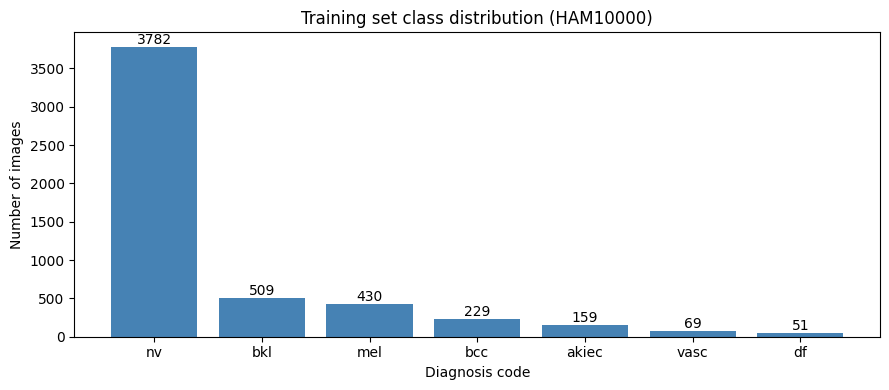


Class legend:
  nv    = melanocytic nevi (benign moles)
  mel   = melanoma
  bkl   = benign keratosis
  bcc   = basal cell carcinoma
  akiec = actinic keratoses
  vasc  = vascular lesions
  df    = dermatofibroma



In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(class_counts.keys(), class_counts.values(), color='steelblue')
ax.bar_label(bars)
ax.set_title('Training set class distribution (HAM10000)')
ax.set_xlabel('Diagnosis code')
ax.set_ylabel('Number of images')
plt.tight_layout()
plt.show()

print("""
Class legend:
  nv    = melanocytic nevi (benign moles)
  mel   = melanoma
  bkl   = benign keratosis
  bcc   = basal cell carcinoma
  akiec = actinic keratoses
  vasc  = vascular lesions
  df    = dermatofibroma
""")

## Sample images per class

Look at a few images from each class before training. Surprises here (corrupted files,
wrong content, inconsistent framing) are much easier to fix now than after a failed training run.

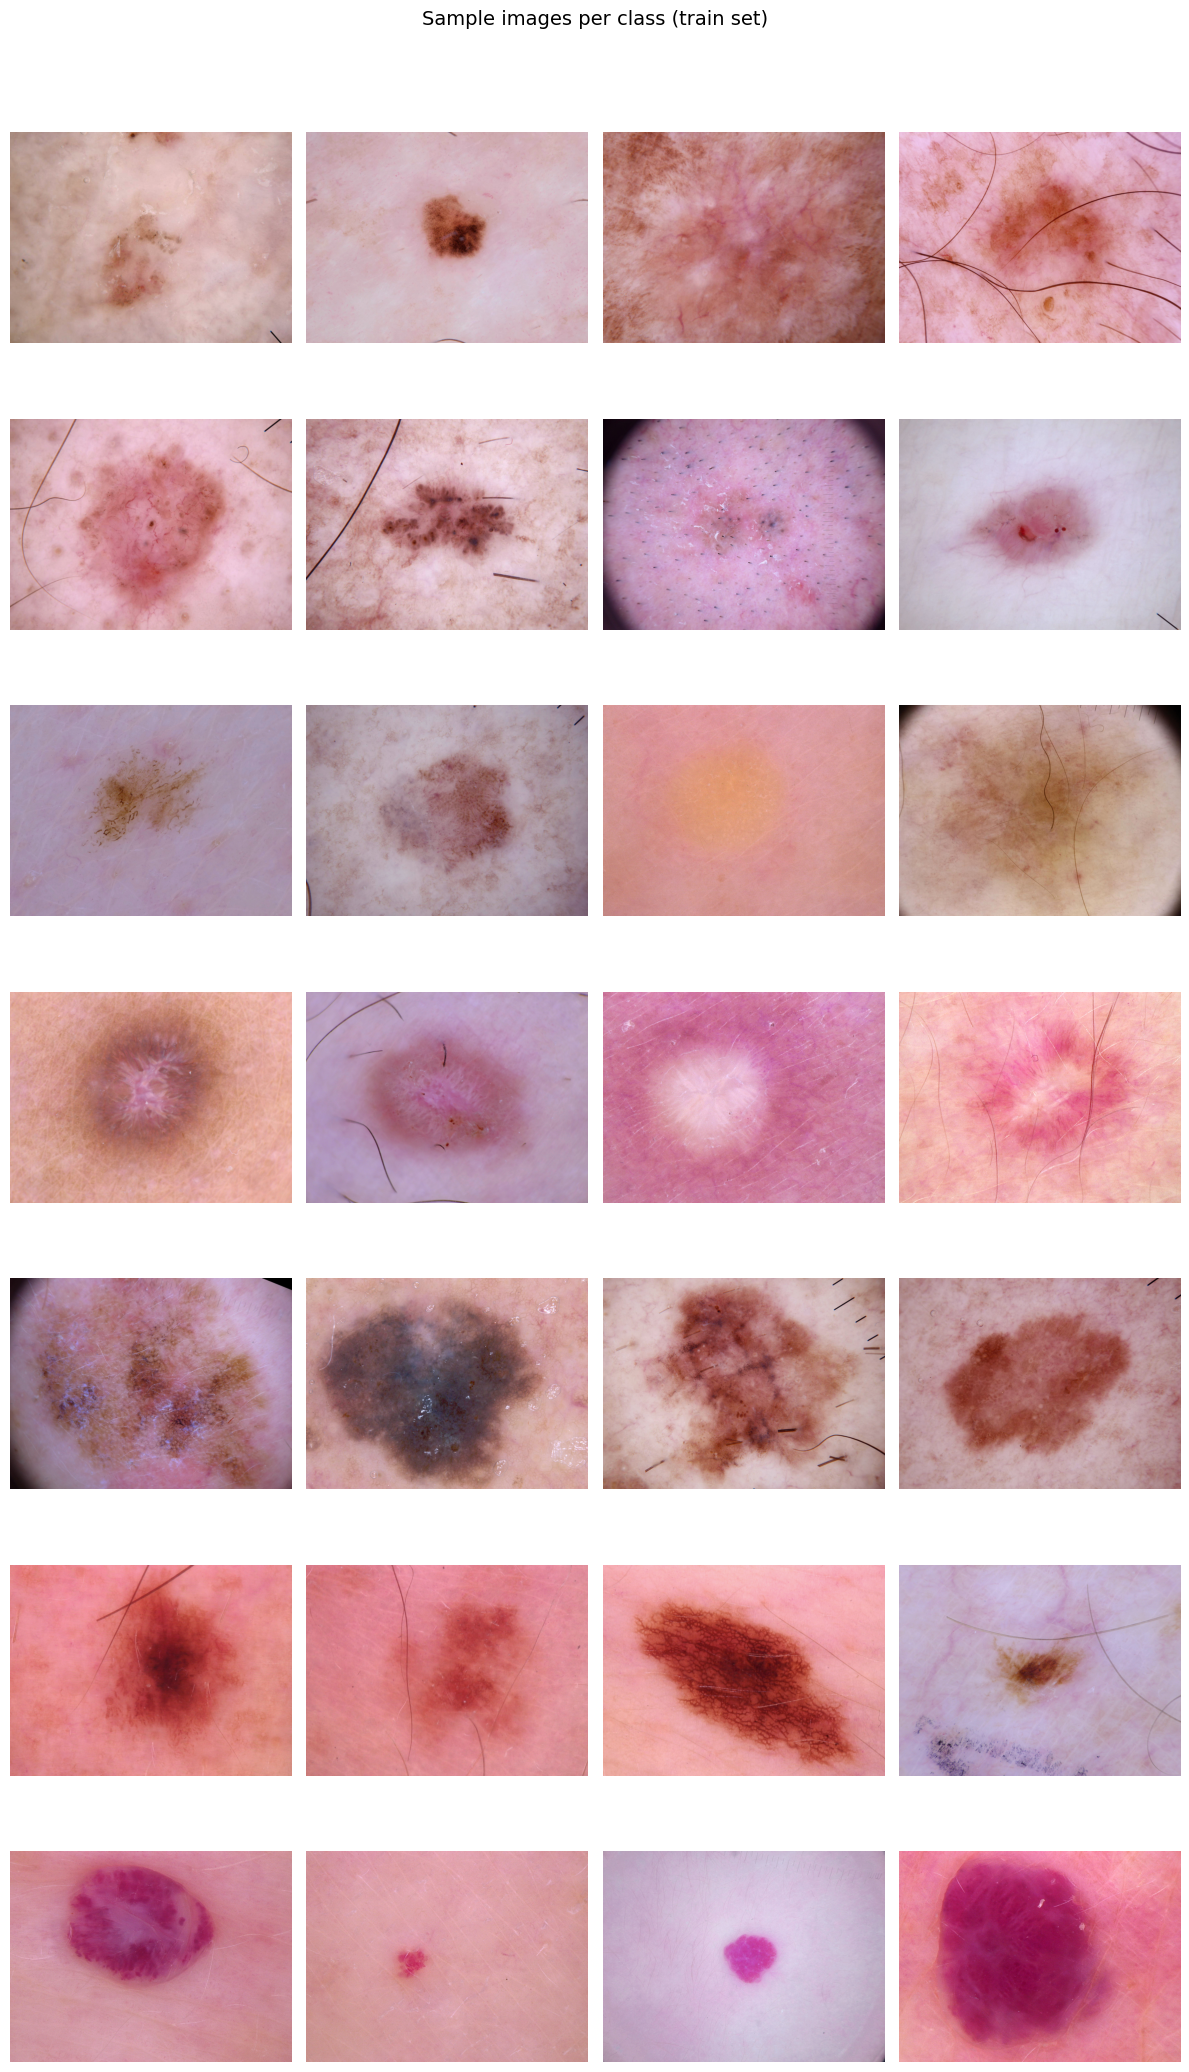

In [5]:
classes = sorted(class_counts.keys())
n_samples = 4

fig, axes = plt.subplots(len(classes), n_samples, figsize=(n_samples * 3, len(classes) * 3))

for row, cls in enumerate(classes):
    images = sorted((train_dir / cls).glob('*.jpg'))[:n_samples]
    for col, img_path in enumerate(images):
        axes[row, col].imshow(mpimg.imread(img_path))
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(cls, fontsize=12, rotation=0, labelpad=40, va='center')

plt.suptitle('Sample images per class (train set)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Image dimensions

Check if all images are the same size. If not, the dataloader's `Resize` transform handles it —
but knowing the native resolution tells us how much information we're throwing away by resizing to 224×224.

In [6]:
from PIL import Image

sizes = set()
sample_paths = list((train_dir / 'nv').glob('*.jpg'))[:50]  # sample 50 from the largest class

for p in sample_paths:
    with Image.open(p) as img:
        sizes.add(img.size)  # (width, height)

print(f"Unique sizes in sample of 50 nv images: {sizes}")
print(f"We resize to 224×224 for the model input.")

Unique sizes in sample of 50 nv images: {(600, 450)}
We resize to 224×224 for the model input.


## Summary and notes for training

Fill this in after running the cells above.

In [7]:
print("Key findings:")
print(f"  Total training images : {total_train}")
print(f"  Number of classes     : {len(class_counts)}")
dominant = list(class_counts.items())[0]
print(f"  Most common class     : {dominant[0]} ({dominant[1]/total_train*100:.0f}% of train)")
print()
print("Imbalance action plan:")
print("  Option A — use weighted loss (torch.nn.CrossEntropyLoss(weight=...))")
print("  Option B — oversample minority classes (WeightedRandomSampler)")
print("  Baseline first: train without any correction, see if nv dominates predictions.")

Key findings:
  Total training images : 5229
  Number of classes     : 7
  Most common class     : nv (72% of train)

Imbalance action plan:
  Option A — use weighted loss (torch.nn.CrossEntropyLoss(weight=...))
  Option B — oversample minority classes (WeightedRandomSampler)
  Baseline first: train without any correction, see if nv dominates predictions.


** This entire notebook (EDA notebook) is counting images, making charts, displaying samples.
- no moving or resizing (this is done in prepare_data.py)
- exploring the data before processing or putting it into a model to get a sense of what it is
- ResNet and EfficientNet are existing neural networks that knows how to "see" edges, textures, shapes, and colors. 
    - the part that I'm "doing" is replacing the final layer to identify images in my context (ie. this is melanoma)
    - ResNet is older but more comprehensive, slow
    - EfficientNet is quicker and similar accuracy but smaller

*flow*


prepare_data.py      → sorted images into train/val/test folders (done)
01-eda.ipynb         → look at the data, understand imbalance (next)
src/data.py          → loads images, resizes to 224×224 at training time
src/model.py         → takes a pretrained ResNet, swaps the last layer
src/train.py         → runs the training loop
02-baseline-resnet   → calls all of the above, produces a trained model
